In [1]:
!pip install transformers datasets torchmetrics pytorch-lightning tqdm matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 23.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AdamW, get_scheduler
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchmetrics.text.rouge import ROUGEScore
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
from torch import nn
import numpy as np
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


device = torch.device("cuda")
print("Using device:", device)

Using device: cuda


In [4]:
from datasets import DatasetDict

# Load datasets and metadata
raw_datasets = DatasetDict({
    "train": load_dataset("json", data_files={"train": "/content/train-open.json"}, split="train[:30%]"),
    "validation": load_dataset("json", data_files="/content/val-open.json", split="train[:15%]"),
    "test": load_dataset("json", data_files="/content/test-open.json", split="train[:15%]"),
})

metadata_path = "/content/all_data_meta.csv"
try:
    metadata = pd.read_csv(metadata_path, on_bad_lines='skip')
    print("Metadata cleaned and loaded successfully. Structure:")
    print(metadata.head())
except Exception as e:
    print("Error loading metadata:", e)

# Clean metadata by dropping rows with missing or invalid values
def clean_metadata(metadata_df):
    metadata_df = metadata_df.dropna()  # Remove rows with missing values
    return metadata_df

metadata = clean_metadata(metadata)

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Metadata cleaned and loaded successfully. Structure:
   answer_id  question_id                                               text  \
0     649960       649960  المعلومات المخزنة أو وسيلة التخزين.\nأي أن الب...   
1     649961       649961   يتكون البايت عادة من 8 بت، ولذلك فأن البايت ي...   
2     649962       649962  لاحظ أن الأسماء كيلوبايت وميجابايت ...الخ، يمك...   
3     649963       649963  وبتمديد النمط، نستطيع الحصول على وحدتين إضافيت...   
4     649959       649959  البايت أو الثُّمَانِيَّة هي وحدة معلومات رقمية...   

   answer_start  answer_end  answer_category                  question  \
0           251         418              NaN      اذكر وسيله التخزين ؟   
1           417         536              NaN       مما يتكون البايت  ؟   
2           748         874              NaN    ما هي مضاعفات البايت ؟   
3           882        1015              NaN  ما هو الاستخدام البايت ؟   
4             0         233              NaN  ما هو البايت ف الحاسوب ؟   

   file_name open-dom

In [5]:
MODEL_NAME = "aubmindlab/aragpt2-base"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token  # Set pad_token to eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.52M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

In [6]:
def preprocess_function(examples):
    # Align metadata fields if necessary
    meta_dict = metadata.set_index("question_id").to_dict("index")
    inputs = []
    for q_id, question, answer in zip(examples["question_id"], examples["question"], examples["answer"]):
        if q_id in meta_dict:
            meta = meta_dict[q_id]
            context = f"Category: {meta['answer_category']} | File: {meta['file_name']}"
        else:
            context = ""
        inputs.append(f"question: {question} context: {context}")

    targets = examples["answer"]
    inputs = tokenizer(inputs, truncation=True, padding="max_length", max_length=256)
    targets = tokenizer(targets, truncation=True, padding="max_length", max_length=256)

    inputs["labels"] = targets["input_ids"]  # Ensure labels align with input_ids
    inputs["attention_mask"] = inputs["attention_mask"]
    return inputs

tokenized_datasets = raw_datasets.map(preprocess_function, batched=True)

def preprocess_function(examples):
    inputs = ["question: " + q for q in examples["question"]]
    targets = examples["answer"]
    inputs = tokenizer(inputs, truncation=True, padding="max_length", max_length=128)
    targets = tokenizer(targets, truncation=True, padding="max_length", max_length=128)

    inputs["labels"] = targets["input_ids"]  # Ensure labels align with input_ids
    inputs["attention_mask"] = inputs["attention_mask"]
    return inputs

tokenized_datasets = raw_datasets.map(preprocess_function, batched=True)

Map:   0%|          | 0/17603 [00:00<?, ? examples/s]

Map:   0%|          | 0/1907 [00:00<?, ? examples/s]

Map:   0%|          | 0/1889 [00:00<?, ? examples/s]

Map:   0%|          | 0/17603 [00:00<?, ? examples/s]

Map:   0%|          | 0/1907 [00:00<?, ? examples/s]

Map:   0%|          | 0/1889 [00:00<?, ? examples/s]

In [7]:
def collate_fn(batch):
    input_ids = pad_sequence([torch.tensor(x["input_ids"]) for x in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = pad_sequence([torch.tensor(x["attention_mask"]) for x in batch], batch_first=True, padding_value=0)
    labels = pad_sequence([torch.tensor(x["labels"]) for x in batch], batch_first=True, padding_value=-100)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

train_dataloader = DataLoader(tokenized_datasets["train"], batch_size=8, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(tokenized_datasets["validation"], batch_size=8, collate_fn=collate_fn)
test_dataloader = DataLoader(tokenized_datasets["test"], batch_size=8, collate_fn=collate_fn)

### Cell 8: Define Optimizer and Scheduler
optimizer = AdamW(model.parameters(), lr=1e-5)
scheduler = get_scheduler(
    "cosine", optimizer=optimizer, num_warmup_steps=50, num_training_steps=len(train_dataloader) * 10
)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [8]:
model.config.dropout = 0.3

def train_epoch(model, dataloader, optimizer, scheduler, history):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for batch in progress_bar:
        optimizer.zero_grad()
        inputs = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=inputs, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    avg_loss = total_loss / len(dataloader)
    history['train_loss'].append(avg_loss)
    return avg_loss

In [9]:
def evaluate_epoch(model, dataloader, history):
    model.eval()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Validation", leave=False)
    with torch.no_grad():
        for batch in progress_bar:
            inputs = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=inputs, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            progress_bar.set_postfix(loss=outputs.loss.item())
    avg_loss = total_loss / len(dataloader)
    history['val_loss'].append(avg_loss)
    return avg_loss

In [10]:
history = {'train_loss': [], 'val_loss': []}
EPOCHS = 5
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, history)
    val_loss = evaluate_epoch(model, val_dataloader, history)
    print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

### Cell 12: Save Fine-Tuned Model
model.save_pretrained("./fine_tuned_gpt2")
tokenizer.save_pretrained("./fine_tuned_gpt2")

Epoch 1/5


Training:   0%|          | 0/2201 [00:00<?, ?it/s]

Validation:   0%|          | 0/239 [00:00<?, ?it/s]

Train Loss: 1.2653, Validation Loss: 1.0165
Epoch 2/5


Training:   0%|          | 0/2201 [00:00<?, ?it/s]

...

Train Loss: 0.9377, Validation Loss: 0.9402
Epoch 5/5


Training:   0%|          | 0/2201 [00:00<?, ?it/s]

Validation:   0%|          | 0/239 [00:00<?, ?it/s]

Train Loss: 0.9160, Validation Loss: 0.9400


('./fine_tuned_gpt2/tokenizer_config.json',
 './fine_tuned_gpt2/special_tokens_map.json',
 './fine_tuned_gpt2/vocab.json',
 './fine_tuned_gpt2/merges.txt',
 './fine_tuned_gpt2/added_tokens.json',
 './fine_tuned_gpt2/tokenizer.json')

In [13]:
def test_model(question):
    inputs = tokenizer("question: " + question, return_tensors="pt", padding=True).to(device)
    outputs = model.generate(inputs["input_ids"], max_length=50)
    print("Answer:", tokenizer.decode(outputs[0], skip_special_tokens=True))

test_question = "What is the capital of egypt"
test_model(test_question)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


Answer: question: What is the capital of egypt


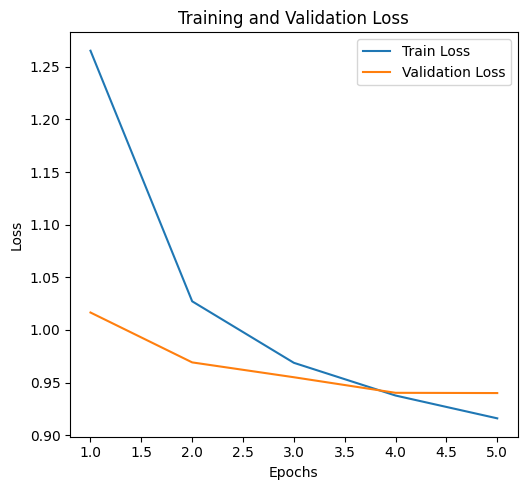

In [14]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(10, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)